# 04 · 설계 휨강도 — 등가직사각형 응력블록과 강도감소계수

원 문서의 `ultimate_bending.ipynb` 에 대응한다.

| 항목 | 식 | 조문 |
|---|---|---|
| 등가직사각형 응력블록 | $\eta(0.85f_{ck})$, $a = \beta_1 c$ | KDS 14 20 20 4.1.1(8) |
| 순인장변형률 | $\varepsilon_t = \varepsilon_{cu}(d_t-c)/c$ | KDS 14 20 20 4.1.2 |
| 강도감소계수 | 0.65~0.85 선형보간 | KDS 14 20 10 4.3.3(2) |
| 최소허용변형률 | 0.004 또는 $2.0\varepsilon_y$ | KDS 14 20 20 4.1.2(5) |
| 최소 철근량 | $\phi M_n \ge 1.2M_{cr}$ | KDS 14 20 20 4.2.2 |

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# 한글 글꼴이 없는 환경에서도 그림이 깨지지 않도록 축 라벨은 ASCII 로 둔다
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 96

In [2]:
from concreteproperties import ConcreteSection
from sectionproperties.pre.library import concrete_rectangular_section

from concreteproperties_kds import KDS


def beam_section(fck=27, fy=400):
    """400 x 600 보 단면 (상부 2-D16, 하부 4-D22, 피복 50 mm)."""
    kds = KDS(column_type="tie")
    conc = kds.create_concrete_material(compressive_strength=fck)
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=600, b=400,
        dia_top=16, area_top=198.6, n_top=2, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=4, c_bot=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    conc_sec = ConcreteSection(geom)
    kds.assign_concrete_section(conc_sec)
    return kds, conc_sec


def column_section(fck=27, fy=400, column_type="tie"):
    """500 x 500 기둥 단면 (8-D22, 피복 50 mm)."""
    kds = KDS(column_type=column_type)
    conc = kds.create_concrete_material(compressive_strength=fck)
    steel = kds.create_steel_material(yield_strength=fy)

    geom = concrete_rectangular_section(
        d=500, b=500,
        dia_top=22, area_top=387.1, n_top=3, c_top=50,
        dia_bot=22, area_bot=387.1, n_bot=3, c_bot=50,
        dia_side=22, area_side=387.1, n_side=1, c_side=50,
        n_circle=16, conc_mat=conc, steel_mat=steel,
    )
    conc_sec = ConcreteSection(geom)
    kds.assign_concrete_section(conc_sec)
    return kds, conc_sec

In [3]:
kds, conc_sec = beam_section()

f_res, u_res, phi = kds.ultimate_bending_capacity(theta=0, n_design=0)
eps_t = kds.net_tensile_strain(theta=0, d_n=u_res.d_n)

print(f"중립축 깊이       c      = {u_res.d_n:.2f} mm")
print(f"응력블록 깊이     a      = {u_res.d_n * 0.80:.2f} mm")
print(f"순인장변형률      et     = {eps_t:.5f}")
print(f"단면 분류                = {kds.section_classification(eps_t=eps_t)}")
print(f"강도감소계수      phi    = {phi:.3f}")
print(f"공칭 휨강도       Mn     = {u_res.m_x / 1e6:.2f} kN.m")
print(f"설계 휨강도   phi*Mn     = {f_res.m_x / 1e6:.2f} kN.m")

중립축 깊이       c      = 76.60 mm
응력블록 깊이     a      = 61.28 mm
순인장변형률      et     = 0.01992
단면 분류                = 인장지배단면
강도감소계수      phi    = 0.850
공칭 휨강도       Mn     = 313.29 kN.m
설계 휨강도   phi*Mn     = 266.30 kN.m


## 극한상태 응력 분포

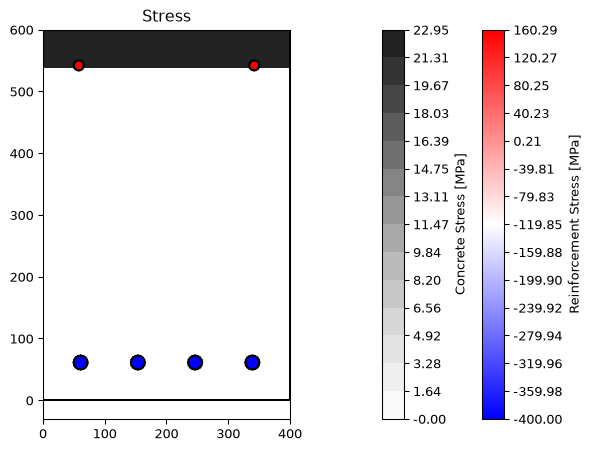

<Axes: title={'center': 'Stress'}>

In [4]:
kds.calculate_ultimate_stress(ultimate_results=u_res).plot_stress()

콘크리트 압축응력이 $\eta(0.85f_{ck}) = 22.95$ MPa, 인장철근 응력이
$-f_y = -400$ MPa 로 나타난다.

## 강도감소계수 곡선 (KDS 14 20 10 4.3.3(2))

$$\phi = \phi_c + (0.85 - \phi_c)
\frac{\varepsilon_t - \varepsilon_y}{\varepsilon_{t,tl}-\varepsilon_y}$$

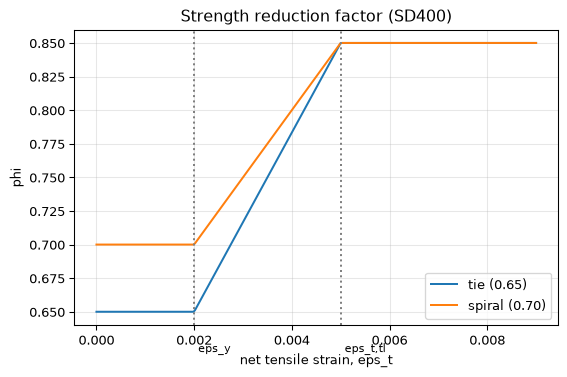

In [5]:
eps = np.linspace(0.0, 0.009, 300)
phi_tie = [kds.capacity_reduction_factor(eps_t=float(e)) for e in eps]

kds_spiral, _ = column_section(column_type="spiral")
phi_spiral = [
    kds_spiral.capacity_reduction_factor(eps_t=float(e)) for e in eps
]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(eps, phi_tie, label="tie (0.65)")
ax.plot(eps, phi_spiral, label="spiral (0.70)")
ax.axvline(kds.eps_y, ls=":", color="grey")
ax.axvline(kds.eps_tl, ls=":", color="grey")
ax.text(kds.eps_y, 0.62, " eps_y", fontsize=8)
ax.text(kds.eps_tl, 0.62, " eps_t,tl", fontsize=8)
ax.set_xlabel("net tensile strain, eps_t")
ax.set_ylabel("phi")
ax.set_title("Strength reduction factor (SD400)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 연성과 최소 철근량 검토

In [6]:
eps_t, eps_min, ok_duct = kds.check_flexural_ductility()
print(f"최소허용변형률  et,min = {eps_min:.5f}   (KDS 14 20 20 4.1.2(5))")
print(f"순인장변형률    et     = {eps_t:.5f}")
print(f"판정                   = {'만족' if ok_duct else '불만족'}")
print()

phi_m_n, m_cr, m_req, ok_min = kds.check_minimum_flexural_reinforcement()
print(f"균열휨모멘트    Mcr    = {m_cr / 1e6:.2f} kN.m")
print(f"요구 강도    1.2*Mcr   = {m_req / 1e6:.2f} kN.m"
      f"   (KDS 14 20 20 4.2.2)")
print(f"설계 휨강도  phi*Mn    = {phi_m_n / 1e6:.2f} kN.m")
print(f"판정                   = {'만족' if ok_min else '불만족'}")

최소허용변형률  et,min = 0.00400   (KDS 14 20 20 4.1.2(5))
순인장변형률    et     = 0.01992
판정                   = 만족



균열휨모멘트    Mcr    = 88.42 kN.m
요구 강도    1.2*Mcr   = 106.10 kN.m   (KDS 14 20 20 4.2.2)
설계 휨강도  phi*Mn    = 266.30 kN.m
판정                   = 만족


## 철근비에 따른 거동

철근량을 늘리면 중립축이 깊어지고 순인장변형률이 줄어, 결국 강도감소계수가
떨어진다.

In [7]:
from concreteproperties import ConcreteSection, add_bar_rectangular_array
from sectionproperties.pre.library import rectangular_section

rows = []
for n_bar in [2, 3, 4, 5, 6, 7, 8]:
    k = KDS()
    c = k.create_concrete_material(compressive_strength=27)
    s = k.create_steel_material(yield_strength=400)
    g = rectangular_section(d=600, b=400, material=c)
    g = add_bar_rectangular_array(
        geometry=g, area=387.1, material=s,
        n_x=n_bar, x_s=(400 - 2 * 60) / (n_bar - 1),
        anchor=(60, 60), n=16,
    )
    k.assign_concrete_section(ConcreteSection(g))
    f, u, p = k.ultimate_bending_capacity()
    e = k.net_tensile_strain(theta=0, d_n=u.d_n)
    rows.append((n_bar * 387.1, e, p, u.m_x / 1e6, f.m_x / 1e6))

print(f"{'As':>8} {'et':>9} {'phi':>7} {'Mn':>9} {'phiMn':>9}")
print("-" * 46)
for a_s, e, p, mn, fmn in rows:
    print(f"{a_s:8.0f} {e:9.5f} {p:7.3f} {mn:9.1f} {fmn:9.1f}")

      As        et     phi        Mn     phiMn
----------------------------------------------
     774   0.03896   0.850     162.0     137.7
    1161   0.02487   0.850     239.1     203.2
    1548   0.01783   0.850     313.6     266.5
    1936   0.01360   0.850     385.4     327.6
    2323   0.01079   0.850     454.7     386.5
    2710   0.00877   0.850     521.3     443.1
    3097   0.00726   0.850     585.3     497.5


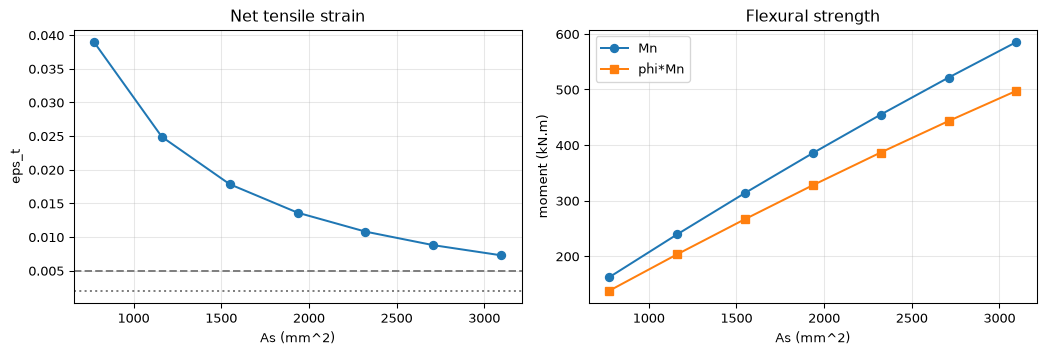

In [8]:
a_s, e, p, mn, fmn = map(np.array, zip(*rows, strict=True))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(a_s, e, "o-")
axes[0].axhline(0.005, ls="--", color="grey")
axes[0].axhline(0.002, ls=":", color="grey")
axes[0].set_xlabel("As (mm^2)")
axes[0].set_ylabel("eps_t")
axes[0].set_title("Net tensile strain")
axes[0].grid(alpha=0.3)

axes[1].plot(a_s, mn, "o-", label="Mn")
axes[1].plot(a_s, fmn, "s-", label="phi*Mn")
axes[1].set_xlabel("As (mm^2)")
axes[1].set_ylabel("moment (kN.m)")
axes[1].set_title("Flexural strength")
axes[1].legend()
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()

철근을 계속 늘려도 $\phi M_n$ 의 증가가 둔해진다. 순인장변형률이
인장지배한계 아래로 내려가 $\phi$ 가 함께 떨어지기 때문이다. KDS 가
최소허용변형률(0.004)을 두는 이유이기도 하다.